[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026_CS1090B_public/blob/main/sec07/cs1090b_sec07_solutions.ipynb)

# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png">

# CS1090B Section 7: Neural Network Review & Autoencoders

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb<br/>

## Overview

In this section, we push further into unsupervised learning by asking a deeper question:

> **How can we learn compact, meaningful representations of complex data and use them to generate new examples?**

We approach this question in three stages, building from familiar neural network foundations toward increasingly powerful generative models.

---

**Part 1: MLPs and CNNs Revisited**

We begin with a review of the two neural network architectures you have already encountered. Beyond recapping how they work, we ask a more provocative question: **how expressive are these models really?** Through a series of conceptual exercises, we examine which classical machine learning models an MLP can theoretically replicate, and think carefully about what that means in practice.

---

**Part 2: Autoencoders (Pneumonia Detection)**

We then introduce **autoencoders**: neural networks trained to compress data into a compact representation and reconstruct it. Working with chest X-ray images from the PneumoniaMNIST dataset, we:

- Connect autoencoders to the dimensionality reduction methods from Section 6 (PCA, UMAP)
- Build a convolutional autoencoder to encode and reconstruct lung X-ray images
- Visualize and interpret the learned latent space

The key insight is that autoencoders learn *task-relevant* compression. Unlike PCA or UMAP, the bottleneck representation is shaped by the data's visual structure, not just its variance.

---

**Part 3: Variational Autoencoders and Conditional Generation**

Finally, we move from compression to **generation**. Standard autoencoders produce unstructured latent spaces that are difficult to sample from meaningfully. Variational Autoencoders (VAEs) fix this by learning a smooth, probabilistic latent space. We extend this to a **Conditional VAE (CVAE)**, which allows us to control *what* we generate. We examine the architecture of a pre-trained CVAE and apply it to our chest X-ray dataset to ask a clinically provocative question: **what would a pneumonia patient's lungs look like if they were healthy?** By encoding an image and flipping its condition label before decoding, we generate a counterfactual visualization, a concrete demonstration of what conditional generation makes possible.


## Learning Objectives

By the end of this section, you should be able to:

### Conceptual Understanding
1. Explain the expressive power of MLPs and which classical machine learning models they can theoretically approximate.
2. Define autoencoders and explain how they generalize dimensionality reduction methods like PCA and UMAP.
3. Interpret the latent space of an autoencoder and explain what the bottleneck representation captures.
4. Explain the key limitation of vanilla autoencoders that motivates variational autoencoders.
5. Describe how VAEs learn a probabilistic latent space and what the reparameterization trick achieves.
6. Explain how CVAEs extend VAEs to enable conditional generation.

### Practical Skills (Autoencoders + Generative Modeling)
7. Build and train a convolutional autoencoder for image reconstruction.
8. Visualize and interpret learned latent representations.
9. Understand the ELBO loss: balancing reconstruction quality against KL divergence regularization.
10. Examine and interpret a pre-trained CVAE architecture and understand how conditioning is implemented.
11. Use a pre-trained CVAE to generate counterfactual images by manipulating condition labels.
12. Critically evaluate generated outputs and understand the limitations of VAE-based generation.

## Setup: Import Libraries & Download Data

In [1]:
# Environment detection and setup
import os
import subprocess
import sys
import shutil
import zipfile
import urllib.request

# --- Download notebook assets (dataset + pre-trained weights) ---
assets_zip_url = "https://github.com/Harvard-CS1090/2026_CS1090B_public/raw/main/sec07/notebook_assets.zip"
assets_zip_name = "notebook_assets.zip"
expected_dirs = ["data"]

all_dirs_exist = all(os.path.isdir(d) for d in expected_dirs)

if all_dirs_exist:
    print("Required directories already exist. Skipping asset download.")
else:
    print(f"Downloading {assets_zip_name} from GitHub...")
    try:
        if 'google.colab' in sys.modules:
            subprocess.run(['wget', '-q', assets_zip_url], check=True)
        else:
            urllib.request.urlretrieve(assets_zip_url, assets_zip_name)
        with zipfile.ZipFile(assets_zip_name, "r") as zip_ref:
            zip_ref.extractall(".")
        os.remove(assets_zip_name)
        if os.path.isdir('__MACOSX'):
            shutil.rmtree('__MACOSX')
        print("Asset download complete.")
    except Exception as e:
        print(f"Error during asset setup: {e}", file=sys.stderr)

print("Setup complete!")

Asset download complete.
Setup complete!


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import warnings

# Visualization
import matplotlib.pyplot as plt

# Dimensionality reduction (for latent space visualization)
from sklearn.decomposition import PCA

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Suppress warnings
warnings.filterwarnings("ignore")

## Part 1: MLPs and CNNs Revisited

### Multilayer Perceptrons (MLPs)

A **Multilayer Perceptron** transforms an input $\mathbf{x}$ through a series of learned linear transformations followed by non-linear activations:

$$\mathbf{h}^{(l)} = \sigma\left(\mathbf{W}^{(l)}\mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

where $\mathbf{W}^{(l)}$ and $\mathbf{b}^{(l)}$ are the weights and biases of layer $l$, and $\sigma$ is an activation function (e.g., ReLU, sigmoid).

Each layer learns increasingly abstract combinations of its inputs. The final layer produces a prediction, and weights are learned end-to-end via backpropagation. The **Universal Approximation Theorem** tells us that a sufficiently wide MLP can approximate any continuous function, a powerful result with important implications for how MLPs relate to other models.

### Convolutional Neural Networks (CNNs)

A **Convolutional Neural Network** applies learned filters across local regions of an input image:

$$(\mathbf{X} * \mathbf{K})_{ij} = \sum_m \sum_n \mathbf{X}_{i+m,\, j+n} \cdot \mathbf{K}_{mn}$$

where $\mathbf{K}$ is a learned convolutional kernel and $*$ denotes the convolution operation.

Unlike MLPs, CNNs exploit the **spatial structure** of images through two key properties: **local connectivity** (each filter sees only a small patch) and **weight sharing** (the same filter is applied across all positions). Stacking convolutional and pooling layers builds hierarchical representations (early layers detect edges, later layers detect shapes and textures) making CNNs far more parameter-efficient than MLPs for image data.

> **❓ Question 1: The Universal Approximation Theorem and CNNs**
>
> 1. In your own words, what does the **Universal Approximation Theorem (UAT)** say? What does it guarantee, and what does it *not* guarantee?
>
> 2. If the UAT tells us a large enough MLP can approximate any function, **why do we bother with CNNs at all?** Give at least two concrete reasons.

<details>
<summary><em>Click to reveal answer</em></summary>

> **Part 1: The UAT**
>
> The UAT states that a feedforward MLP with at least one hidden layer and a non-linear activation function can approximate **any continuous function** to arbitrary precision, provided the network is wide enough.
>
> However, it says nothing about:
> - **How many neurons are actually needed** (could be astronomically large)
> - **Whether gradient descent will find the solution** (optimization is not guaranteed)
> - **How well the network generalizes** to unseen data
>
> In short: the UAT is an existence result, not a practical recipe.
>
> **Part 2: Why CNNs?**
>
> 1. **Parameter efficiency**: An MLP applied to a 224x224 image treats all 50,176 pixels as independent inputs. A CNN instead learns small filters shared across the entire image, exploiting the fact that a useful edge detector in the top-left corner is equally useful in the bottom-right. This drastically reduces the number of parameters needed.
>
> 2. **Inductive bias**: CNNs are architecturally biased toward spatial patterns. They build in the assumption that nearby pixels are related and that patterns can appear anywhere in the image. An MLP has no such prior and must learn these spatial relationships from scratch, requiring far more data and compute.
>
> 3. **Practical trainability**: Even if an MLP *could* theoretically match a CNN's performance, it would require so many parameters that training becomes computationally infeasible and highly prone to overfitting.

</details>

> **✏️ Exercise 1: Can an MLP Approximate It?**
>
> A neural network is a **universal function approximator**: given enough capacity, it can learn any continuous input-output mapping. With this in mind, for each classical model below, answer:
> 1. Can an MLP approximate it? (Yes/No)
> 2. If yes, sketch the MLP architecture that would achieve this: describe the layers, activations, and loss function.
>
> | Model | Can an MLP approximate it? | Architecture Sketch |
> |---|---|---|
> | Linear Regression | ? | ? |
> | Logistic Regression | ? | ? |
> | K-Nearest Neighbors | ? | ? |
> | Decision Tree | ? | ? |
> | Random Forest | ? | ? |

<details>
<summary><em>Click to reveal answer</em></summary>

> | Model | Can an MLP approximate it? | Architecture Sketch |
> |---|---|---|
> | Linear Regression | **Yes** | Single neuron, no activation, MSE loss: $\hat{y} = \mathbf{W}\mathbf{x} + b$. This *is* a one-layer MLP. |
> | Logistic Regression | **Yes** | Single neuron, sigmoid activation, binary cross-entropy loss: $\hat{y} = \sigma(\mathbf{W}\mathbf{x} + b)$. Also *is* a one-layer MLP. |
> | K-Nearest Neighbors | **Yes** | KNN produces piecewise constant decision boundaries. A deep ReLU network can approximate these arbitrarily well: each neuron approximates one threshold boundary. The MLP learns the same input-output mapping without ever storing training points. |
> | Decision Tree | **Yes** | Map each level of splits to one hidden layer: each neuron approximates one threshold test using ReLU. The next layer combines these to identify which leaf a point falls into. A tree of depth $D$ with $N$ total nodes needs $\sim D$ layers of width $\sim N$. |
> | Random Forest | **Yes** | Since each tree is approximable, a forest of $T$ trees can be approximated by $T$ parallel tree-like sub-networks whose outputs are averaged in a final layer. |
>
> **The key insight**: The answer is yes everywhere — the UAT guarantees this. What differs is *how much network capacity is needed*. Linear and logistic regression are trivially one-layer MLPs. KNN, decision trees, and random forests require increasing depth and width to approximate their more complex decision boundaries.

</details>

> **❓ Question 2: MLP and CNN Quantitative Questions**
>
> **Q2.1 - Parameter Counting**
>
> You have a $32 \times 32$ grayscale image. Compare the number of trainable parameters in the first layer of:
>
> - **(a)** An MLP with a first hidden layer of 256 neurons
> - **(b)** A CNN with 16 filters of size $3 \times 3$, no padding, stride 1
>
> Show your work. What does the difference suggest?
>
> **Q2.2 - Output Dimensions**
>
> A convolutional layer receives an input of size $H \times W \times C$ and produces an output according to:
>
> $$H_{out} = \left\lfloor \frac{H - F + 2P}{S} \right\rfloor + 1$$
>
> where $F$ is the filter size, $P$ is padding, and $S$ is stride. Given:
> - Input: $64 \times 64 \times 3$
> - 32 filters of size $5 \times 5$
> - Padding $P = 1$, Stride $S = 2$
>
> **(a)** What is the output spatial dimension $H_{out} \times W_{out}$?
>
> **(b)** What is the full output shape including channels?
>
> **(c)** How many trainable parameters does this layer have (including biases)?

<details>
<summary><em>Click to reveal answer</em></summary>

> **Q2.1**
>
> **(a) MLP**: Each of the 256 neurons connects to all $32 \times 32 = 1{,}024$ inputs, plus one bias per neuron:
> $$1{,}024 \times 256 + 256 = 262{,}400 \text{ parameters}$$
>
> **(b) CNN**: Each filter has $3 \times 3 \times 1 = 9$ weights plus 1 bias, for 16 filters:
> $$16 \times (9 + 1) = 160 \text{ parameters}$$
>
> The CNN uses **~1,640x fewer parameters** in its first layer. This is the power of weight sharing: the same 9-weight filter is reused across every spatial position.
>
> **Q2.2**
>
> **(a)** Applying the formula with $H=64$, $F=5$, $P=1$, $S=2$:
> $$H_{out} = \left\lfloor \frac{64 - 5 + 2}{2} \right\rfloor + 1 = \left\lfloor \frac{61}{2} \right\rfloor + 1 = 30 + 1 = 31$$
> Output spatial dimensions: $31 \times 31$
>
> **(b)** Full output shape: $31 \times 31 \times 32$
>
> **(c)** Each filter has $5 \times 5 \times 3 = 75$ weights plus 1 bias, for 32 filters:
> $$32 \times (75 + 1) = 2{,}432 \text{ parameters}$$

</details>

## Part 2: Autoencoders

In Part 1, we saw that an MLP is a **universal function approximator** that generalizes classical models like linear regression, logistic regression, and decision trees into a single, more powerful framework. Autoencoders do the same thing for dimensionality reduction.

Recall from Section 6 that PCA finds linear projections of maximum variance, and UMAP preserves local neighborhood structure through a carefully constructed graph. Both are hand-crafted algorithms with specific assumptions baked in. An **autoencoder** generalizes this idea: it is a neural network trained to compress data into a low-dimensional representation and reconstruct it, learning the best possible mapping directly from the data itself. No linearity assumption, no neighborhood graph, no manual hyperparameter tuning. Just a learned compression.

We will be working with the **PneumoniaMNIST** dataset, a collection of 5,856 chest X-ray images labeled as either healthy or pneumonia-positive. Each image is 64x64 pixels, giving us **4,096 dimensions** per image. Our goal is to:

1. **Understand** autoencoders and their connection to the dimensionality reduction methods from Section 6
2. **Build** a convolutional autoencoder to compress and reconstruct chest X-ray images
3. **Visualize** the learned latent space and interpret what it captures

Let's start by visualizing some examples from our dataset:

PNEUMONIAMNIST DATASET SUMMARY

Split        Images               Labels
Train        (4708, 64, 64)       (4708,)
Validation   (524, 64, 64)        (524,)
Test         (624, 64, 64)        (624,)

Label Encoding:  0 = Normal  |  1 = Pneumonia

Class Balance (Train):

  Normal:    1214 (25.8%)
  Pneumonia: 3494 (74.2%)


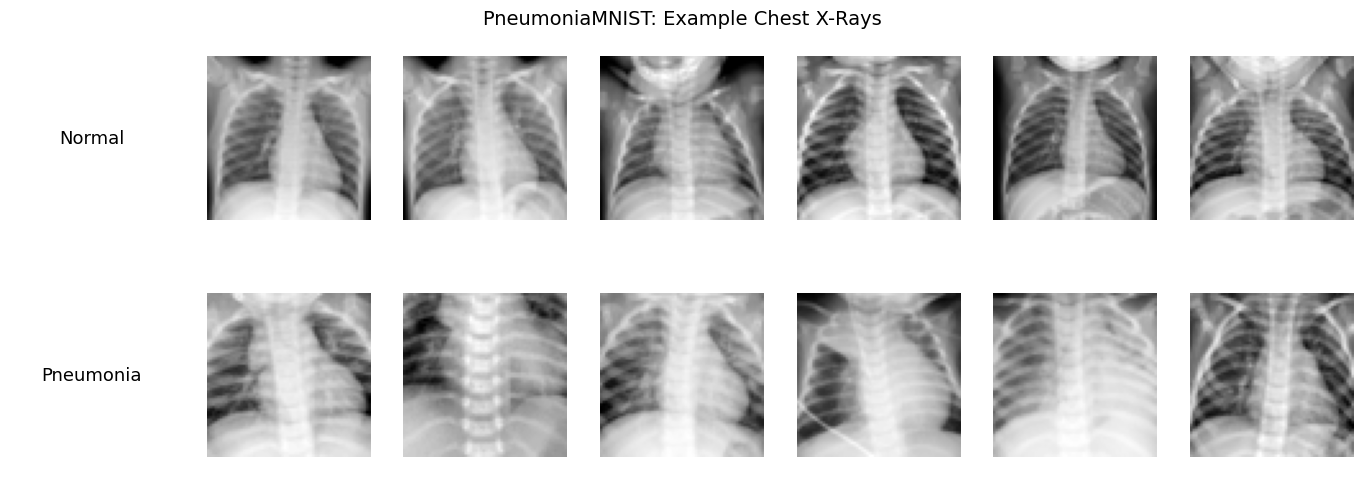

In [3]:
# Load the dataset
data = np.load('data/pneumoniamnist_64.npz')

# Unpack splits
X_train, y_train = data['train_images'], data['train_labels'].flatten()
X_val, y_val     = data['val_images'],   data['val_labels'].flatten()
X_test, y_test   = data['test_images'],  data['test_labels'].flatten()

# Print dataset summary
print("PNEUMONIAMNIST DATASET SUMMARY\n")
print(f"{'Split':<12} {'Images':<20} {'Labels'}")
print(f"{'Train':<12} {str(X_train.shape):<20} {y_train.shape}")
print(f"{'Validation':<12} {str(X_val.shape):<20} {y_val.shape}")
print(f"{'Test':<12} {str(X_test.shape):<20} {y_test.shape}")
print(f"\nLabel Encoding:  0 = Normal  |  1 = Pneumonia")
print(f"\nClass Balance (Train):\n")
print(f"  Normal:    {np.sum(y_train == 0):>4d} ({100*np.mean(y_train == 0):.1f}%)")
print(f"  Pneumonia: {np.sum(y_train == 1):>4d} ({100*np.mean(y_train == 1):.1f}%)")

# Visualize examples
np.random.seed(1090)
label_names = ['Normal', 'Pneumonia']
fig, axes = plt.subplots(2, 7, figsize=(14, 5))

for i, label in enumerate(label_names):
    # First column: row label
    axes[i, 0].text(0.5, 0.5, label, fontsize=13, va='center', ha='center',
                    transform=axes[i, 0].transAxes)
    axes[i, 0].axis('off')
    
    # Remaining columns: images
    idxs = np.where(y_train == i)[0]
    sampled = np.random.choice(idxs, 6, replace=False)
    
    for j, idx in enumerate(sampled):
        ax = axes[i, j + 1]
        ax.imshow(X_train[idx], cmap='gray')
        ax.axis('off')

plt.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.05)
plt.suptitle('PneumoniaMNIST: Example Chest X-Rays', fontsize=14)
plt.show()

### What is an Autoencoder?

An **autoencoder** is a neural network trained to reconstruct its own input. It consists of two components:

- The **encoder** $f_\phi$ compresses the input $\mathbf{x}$ into a low-dimensional **latent representation** $\mathbf{z}$:
$$\mathbf{z} = f_\phi(\mathbf{x})$$

- The **decoder** $g_\theta$ reconstructs the original input from $\mathbf{z}$:
$$\hat{\mathbf{x}} = g_\theta(\mathbf{z})$$

The network is trained end-to-end by minimizing the **reconstruction loss** between the input and its reconstruction:

$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \|\mathbf{x}_i - \hat{\mathbf{x}}_i\|^2$$

The key insight is the **bottleneck**: by forcing the data through a low-dimensional $\mathbf{z}$, the network must learn to retain only the most important structure. This is exactly the same intuition as PCA and UMAP, but now the compression function is a learned neural network rather than a hand-crafted algorithm. In fact, if both the encoder and decoder are single linear layers with no activations, an autoencoder is mathematically equivalent to PCA.

For image data, we use **convolutional layers** in both the encoder and decoder. The encoder uses convolutions and pooling to progressively downsample the image into $\mathbf{z}$, while the decoder uses transposed convolutions to upsample back to the original resolution.

### Building a Convolutional Autoencoder

The architecture follows an **encoder-bottleneck-decoder** structure. The encoder progressively compresses the 64x64 image into a 64-dimensional latent vector $\mathbf{z}$, and the decoder mirrors this process in reverse:

```
Input (1, 64, 64) → [Encoder] → z (64,) → [Decoder] → Reconstruction (1, 64, 64)
```

Let's start by setting up our data loaders:

In [4]:
# Normalize and add channel dimension: (N, 64, 64) -> (N, 1, 64, 64)
X_train_t = torch.tensor(X_train / 255.0, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val   / 255.0, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test  / 255.0, dtype=torch.float32).unsqueeze(1)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=64, shuffle=False)

print(f"Train Batches: {len(train_loader)}  |  Val Batches: {len(val_loader)}  |  Test Batches: {len(test_loader)}")

Train Batches: 74  |  Val Batches: 9  |  Test Batches: 10


> **✏️ Exercise 2: Build the Decoder**
>
> Complete the decoder by filling in `decoder_fc` and `decoder_conv`. The decoder should be a mirror image of the encoder:
>
> - **`decoder_fc`**: Two linear layers that project from `latent_dim` back up to `64 * 8 * 8`, with ReLU activations between them. This mirrors the two linear layers at the end of the encoder.
>
> - **`decoder_conv`**: Three `ConvTranspose2d` layers that upsample from `(64, 8, 8)` back to `(1, 64, 64)`, reversing the encoder's three conv blocks. End with `Sigmoid` to map pixel values back to $[0, 1]$.
>
> **Hint**: `nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)` is the spatial inverse of `MaxPool2d(2)`: it doubles the spatial dimensions.

In [5]:
LATENT_DIM = 64

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        
        # Encoder (provided)
        # Progressively halves spatial dimensions using MaxPool2d(2)
        # then projects to latent space via two linear layers
        self.encoder = nn.Sequential(
            # Block 1: (batch, 1,  64, 64) -> (batch, 16, 32, 32)
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # Block 2: (batch, 16, 32, 32) -> (batch, 32, 16, 16)
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # Block 3: (batch, 32, 16, 16) -> (batch, 64,  8,  8)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # Project to latent space
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        
        # Decoder (your turn!)
        # decoder_fc:   project from latent_dim back up to (64 * 8 * 8)
        # decoder_conv: upsample from (64, 8, 8) back to (1, 64, 64)
        
        self.decoder_fc = nn.Sequential(
            # Input:  (batch, latent_dim)
            # YOUR CODE HERE
            # BEGIN SOLUTION
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 64 * 8 * 8), nn.ReLU()
            # END SOLUTION
            # Output: (batch, 64 * 8 * 8)
        )
        
        self.decoder_conv = nn.Sequential(
            # Input:  (batch, 64, 8, 8) -- after reshape in decode()
            # YOUR CODE HERE
            # BEGIN SOLUTION
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(16,  1, kernel_size=2, stride=2), nn.Sigmoid()
            # END SOLUTION
            # Output: (batch, 1, 64, 64)
        )
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 64, 8, 8)
        return self.decoder_conv(x)
    
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

Using device: mps

Epoch  1/25  |  Train Loss: 0.0215  |  Val Loss: 0.0185
Epoch  2/25  |  Train Loss: 0.0144  |  Val Loss: 0.0114
Epoch  3/25  |  Train Loss: 0.0103  |  Val Loss: 0.0089
Epoch  4/25  |  Train Loss: 0.0079  |  Val Loss: 0.0069
Epoch  5/25  |  Train Loss: 0.0062  |  Val Loss: 0.0057
Epoch  6/25  |  Train Loss: 0.0053  |  Val Loss: 0.0051
Epoch  7/25  |  Train Loss: 0.0048  |  Val Loss: 0.0046
Epoch  8/25  |  Train Loss: 0.0044  |  Val Loss: 0.0043
Epoch  9/25  |  Train Loss: 0.0041  |  Val Loss: 0.0040
Epoch 10/25  |  Train Loss: 0.0038  |  Val Loss: 0.0038
Epoch 11/25  |  Train Loss: 0.0036  |  Val Loss: 0.0037
Epoch 12/25  |  Train Loss: 0.0035  |  Val Loss: 0.0036
Epoch 13/25  |  Train Loss: 0.0034  |  Val Loss: 0.0035
Epoch 14/25  |  Train Loss: 0.0033  |  Val Loss: 0.0034
Epoch 15/25  |  Train Loss: 0.0032  |  Val Loss: 0.0034
Epoch 16/25  |  Train Loss: 0.0031  |  Val Loss: 0.0033
Epoch 17/25  |  Train Loss: 0.0031  |  Val Loss: 0.0032
Epoch 18/25  |  Train Loss: 0

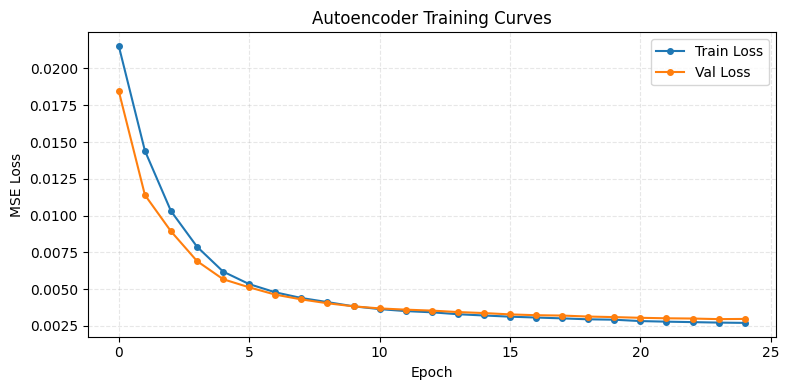

In [6]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}\n")

# Training loop
def train_autoencoder(model, train_loader, val_loader, epochs=50):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), x)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                val_loss += criterion(model(x), x).item()
        
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        print(f"Epoch {epoch:>2d}/{epochs}  |  Train Loss: {train_losses[-1]:.4f}  |  Val Loss: {val_losses[-1]:.4f}")
    
    return train_losses, val_losses

# Train
torch.manual_seed(1090)
model = Autoencoder(latent_dim=LATENT_DIM)
train_losses, val_losses = train_autoencoder(model, train_loader, val_loader, epochs=25)

print("\n\n")

# Plot training curves
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(train_losses, 'o-', label='Train Loss', markersize=4)
ax.plot(val_losses,   'o-', label='Val Loss',   markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training Curves')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluating Reconstructions

Now that the model is trained, let's see how well it can compress and reconstruct chest X-ray images it has never seen before. For each test image, the autoencoder encodes it into a 64-dimensional vector and then decodes it back to 64x64 pixels. Good reconstructions would suggest the latent space has captured the essential visual structure of the X-rays.

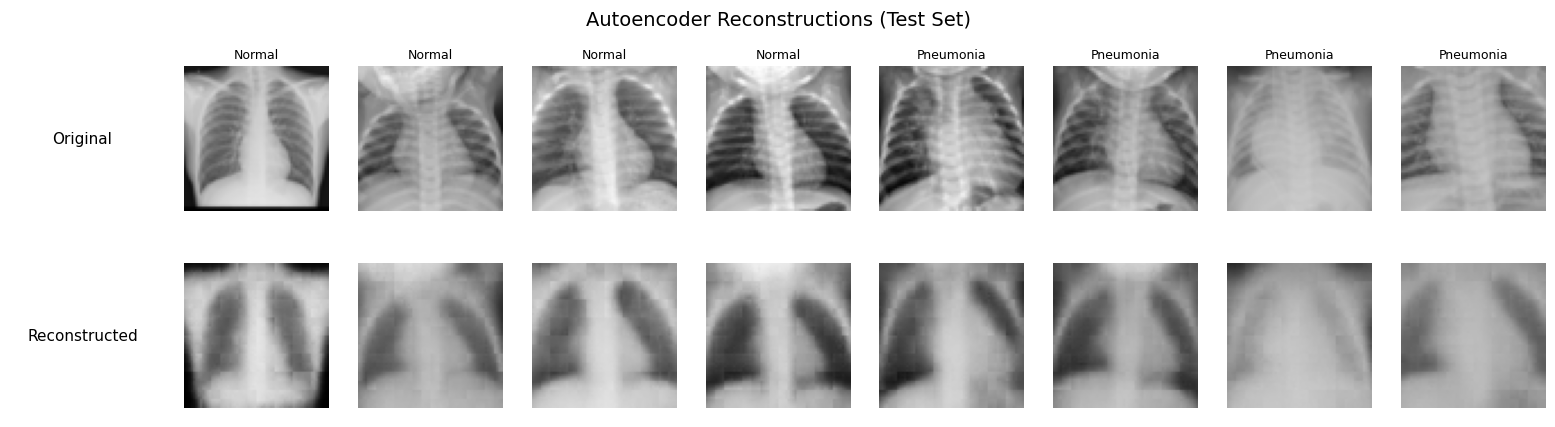

In [7]:
np.random.seed(1090)
model.eval()

normal_idxs    = np.where(y_test == 0)[0]
pneumonia_idxs = np.where(y_test == 1)[0]
idxs = np.concatenate([np.random.choice(normal_idxs,    4, replace=False),
                        np.random.choice(pneumonia_idxs, 4, replace=False)])

with torch.no_grad():
    x_orig  = X_test_t[idxs].to(device)
    x_recon = model(x_orig).cpu().numpy()
    x_orig  = x_orig.cpu().numpy()

fig, axes = plt.subplots(2, 9, figsize=(16, 4))

for row, row_label in enumerate(['Original', 'Reconstructed']):
    axes[row, 0].text(0.5, 0.5, row_label, fontsize=11, va='center', ha='center',
                      transform=axes[row, 0].transAxes)
    axes[row, 0].axis('off')

for j in range(8):
    axes[0, j+1].imshow(x_orig[j, 0],  cmap='gray', vmin=0, vmax=1)
    axes[1, j+1].imshow(x_recon[j, 0], cmap='gray', vmin=0, vmax=1)
    for row in range(2):
        axes[row, j+1].axis('off')
    axes[0, j+1].set_title('Normal' if y_test[idxs[j]] == 0 else 'Pneumonia', fontsize=9)

plt.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.02)
plt.suptitle('Autoencoder Reconstructions (Test Set)', fontsize=14, y = 1.04)
plt.show()

### Visualizing the Latent Space

The reconstructions look reasonable, though not terrific. That said, recall what the autoencoder is doing: compressing each image from $64 \times 64 = 4{,}096$ dimensions down to just 64, a **64x reduction** in dimensionality. The fact that the reconstructions are recognizable at all suggests the latent space has captured meaningful visual structure.

But what exactly has it captured? Let's look inside the bottleneck. We'll take the 64-dimensional encodings of all test images and project them down to 2D using PCA, coloring each point by its true label. As a baseline, we'll do the same with the raw pixel data to see how much the autoencoder's learned representation improves the separation between Normal and Pneumonia cases.

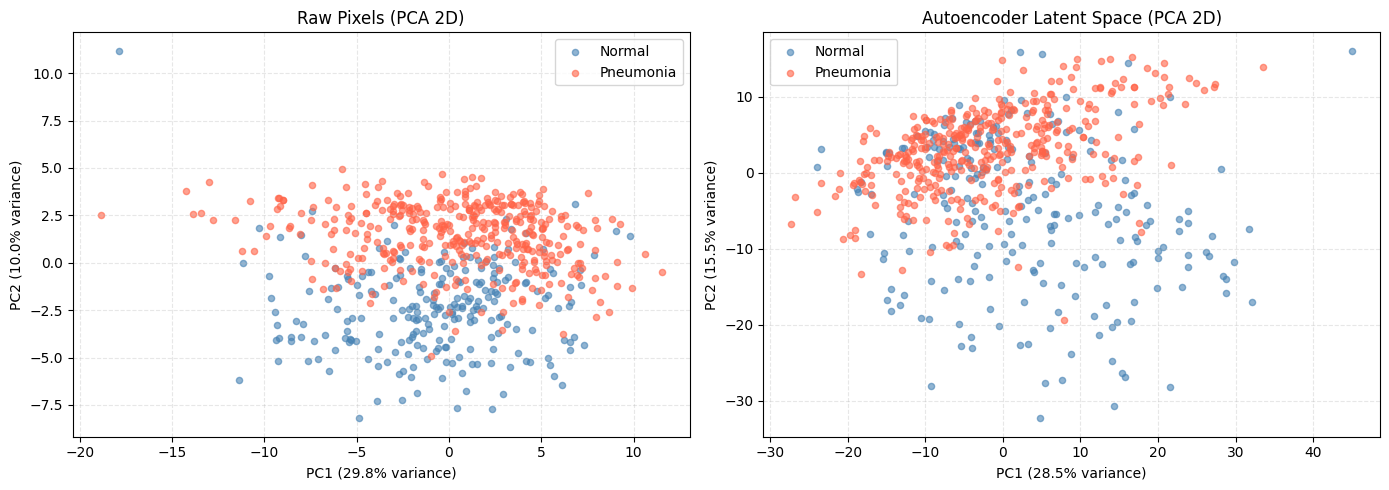

In [8]:
# Encode all test images
model.eval()
with torch.no_grad():
    z_test = model.encode(X_test_t.to(device)).cpu().numpy()

# PCA on raw pixels
X_test_flat = X_test.reshape(len(X_test), -1) / 255.0
pca_raw = PCA(n_components=2, random_state=1090)
z_raw_2d = pca_raw.fit_transform(X_test_flat)

# PCA on latent encodings
pca_latent = PCA(n_components=2, random_state=1090)
z_latent_2d = pca_latent.fit_transform(z_test)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

titles  = ['Raw Pixels (PCA 2D)', 'Autoencoder Latent Space (PCA 2D)']
pcas    = [pca_raw, pca_latent]
embeds  = [z_raw_2d, z_latent_2d]

for ax, title, pca, embed in zip(axes, titles, pcas, embeds):
    for label, name, color in zip([0, 1], ['Normal', 'Pneumonia'], ['steelblue', 'tomato']):
        mask = y_test == label
        ax.scatter(embed[mask, 0], embed[mask, 1],
                   label=name, color=color, alpha=0.6, s=20)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

> **❓ Question 3: Comparing Raw and Latent Space Projections**
>
> Look at the two PCA projections above: raw pixel space vs. the autoencoder's latent space.
>
> 1. The two plots look somewhat similar in terms of class separation. What does this tell us about what the autoencoder preserved during compression? Was the clinically relevant information lost?
>
> 2. Neither plot shows clean separation between Normal and Pneumonia cases. Should we expect better separation? What would need to be different about the model for the latent space to more clearly separate the two classes?

<details>
<summary><em>Click to reveal answer</em></summary>

> 1. **The autoencoder preserved the class structure**: Even though it was never told about labels, the visual differences between healthy and pneumonia X-rays are real enough that the autoencoder had to encode them to reconstruct images accurately. The compression did not throw away the clinically relevant signal: it is still there in the 64-dimensional latent space, and PCA can partially recover it.
>
> 2. **We should not expect clean separation here, because we never asked for it.** The autoencoder optimizes for reconstruction, not class separation. The latent space organizes itself around all sources of visual variation: patient size, image brightness, lung orientation, and disease status, with no preference for any one of them. To get a latent space that explicitly organizes around disease status, we would need a model that is aware of labels during training. This is exactly what a **Conditional VAE** does: by conditioning the model on the class label, we can learn a latent space where disease status is an explicit, controllable axis, which means we can not only separate the classes but generate new images with a specific condition. That is what we will build in Part 3.

</details>

## Part 3: Variational Autoencoders and Conditional Generation

In Part 2, we saw that a standard autoencoder learns a compact latent representation that preserves clinically relevant structure, but has no mechanism to organize or control that structure. The latent space is essentially unstructured: points are placed wherever is convenient for reconstruction, with no guarantee that the space between them is meaningful. If you sample a random point from this space and decode it, you will likely get a blurry or incoherent image, because most of the latent space was never visited during training.

A **Variational Autoencoder (VAE)** fixes this by learning a *probabilistic* latent space. Instead of encoding an image as a single point $\mathbf{z}$, the encoder outputs a distribution:

$$q(\mathbf{z} | \mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}(\mathbf{x}),\, \boldsymbol{\sigma}^2(\mathbf{x}))$$

The model is then trained to keep this distribution close to a standard normal prior $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ via KL divergence regularization, while still reconstructing the input accurately. This forces the latent space to be smooth and continuous, meaning you can sample from it meaningfully.

A **Conditional VAE (CVAE)** extends this further by conditioning both the encoder and decoder on a label $\mathbf{c}$:

$$q(\mathbf{z} | \mathbf{x}, \mathbf{c}) = \mathcal{N}(\boldsymbol{\mu}(\mathbf{x}, \mathbf{c}),\, \boldsymbol{\sigma}^2(\mathbf{x}, \mathbf{c}))$$

This means the label becomes an explicit, controllable input at generation time. We are no longer just compressing and reconstructing: we can encode an image under one condition and decode it under another.

Applied to our chest X-ray dataset, this raises a clinically fascinating question: **what would a pneumonia patient's lungs look like if they were healthy?** By encoding a pneumonia X-ray and swapping the condition label to "Normal" before decoding, we can generate a counterfactual visualization. We will examine the architecture of a pre-trained CVAE and then use it to explore this question directly.

### The VAE Loss Function

A standard autoencoder minimizes reconstruction loss alone. A VAE must balance two competing objectives, formalized as the **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}_{\text{ELBO}} = \underbrace{\mathbb{E}_{q(\mathbf{z}|\mathbf{x})}\left[\log p(\mathbf{x}|\mathbf{z})\right]}_{\text{reconstruction term}} - \underbrace{D_{\text{KL}}\left(q(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z})\right)}_{\text{regularization term}}$$

- **Reconstruction term**: How well does the decoder rebuild the input from $\mathbf{z}$? This is the same MSE loss as before.
- **KL divergence term**: How close is the learned posterior $q(\mathbf{z}|\mathbf{x})$ to the standard normal prior $p(\mathbf{z})$? This penalizes encodings that stray too far from $\mathcal{N}(\mathbf{0}, \mathbf{I})$.

For a Gaussian encoder, the KL term has a closed form:

$$D_{\text{KL}} = -\frac{1}{2}\sum_{j=1}^{d}\left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

The tension between these two terms is what makes VAEs powerful: the reconstruction term wants to encode each image precisely, while the KL term forces all encodings to overlap with the standard normal. The result is a smooth, well-organized latent space where nearby points decode to similar images.

### The Reparameterization Trick

There is one subtle problem: sampling $\mathbf{z} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\sigma}^2)$ is not differentiable, so we cannot backpropagate through it. The **reparameterization trick** resolves this by rewriting the sample as:

$$\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

The randomness is now in $\boldsymbol{\epsilon}$, which has no learnable parameters. Gradients flow cleanly through $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$ during backpropagation.

### The CVAE Architecture and Training

Below we define the full CVAE architecture and training loop. The key differences from our standard autoencoder are:

- The **encoder** outputs two vectors, $\boldsymbol{\mu}$ and $\log \boldsymbol{\sigma}^2$, rather than a single point
- A **label embedding** is concatenated to both the encoder and decoder inputs, conditioning the model on disease status
- The **reparameterization trick** allows gradients to flow through the sampling step
- The **loss function** combines reconstruction loss with KL divergence regularization

Take a moment to read through the architecture and identify where each of these differences appears in the code.

In [9]:
LATENT_DIM  = 64
NUM_CLASSES = 2

class CVAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.latent_dim = latent_dim

        # Label embedding: maps class label to a vector concatenated with encoder output
        self.label_embedding = nn.Embedding(num_classes, 64 * 8 * 8)

        # Encoder: same conv blocks as autoencoder, but outputs mu and log_var
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.fc_mu      = nn.Linear(64 * 8 * 8 + 64 * 8 * 8, latent_dim)
        self.fc_log_var = nn.Linear(64 * 8 * 8 + 64 * 8 * 8, latent_dim)

        # Decoder: conditioned on both z and the label embedding
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim + 64 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, 64 * 8 * 8), nn.ReLU()
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(16,  1, kernel_size=2, stride=2), nn.Sigmoid()
        )

    def encode(self, x, c):
        h     = self.encoder_conv(x)
        c_emb = self.label_embedding(c)
        h     = torch.cat([h, c_emb], dim=1)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z, c):
        c_emb = self.label_embedding(c)
        x     = self.decoder_fc(torch.cat([z, c_emb], dim=1))
        x     = x.view(-1, 64, 8, 8)
        return self.decoder_conv(x)

    def forward(self, x, c):
        mu, log_var = self.encode(x, c)
        z           = self.reparameterize(mu, log_var)
        return self.decode(z, c), mu, log_var

In [10]:
# Loss function: reconstruction loss + KL divergence
def vae_loss(x, x_recon, mu, log_var):
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_loss

# Training loop
def train_cvae(model, train_loader, val_loader, epochs=100):
    model      = model.to(device)
    optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_losses, val_losses = [], []
    best_val_loss = float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for x, c in train_loader:
            x, c = x.to(device), c.to(device)
            optimizer.zero_grad()
            x_recon, mu, log_var = model(x, c)
            loss = vae_loss(x, x_recon, mu, log_var)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, c in val_loader:
                x, c = x.to(device), c.to(device)
                x_recon, mu, log_var = model(x, c)
                val_loss += vae_loss(x, x_recon, mu, log_var).item()

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss   / len(val_loader))
        print(f"Epoch {epoch:>2d}/{epochs}  |  Train Loss: {train_losses[-1]:.1f}  |  Val Loss: {val_losses[-1]:.1f}")

        # Save best model
        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            torch.save(model.state_dict(), 'data/cvae_weights.pth')
            print(f"  -> Best model saved (val loss: {best_val_loss:.1f})")

    return train_losses, val_losses

# Training is commented out as we will use the pre-trained model below

# torch.manual_seed(1090)
# cvae = CVAE(latent_dim = LATENT_DIM, num_classes = NUM_CLASSES)
# train_losses, val_losses = train_cvae(cvae, train_loader, val_loader, epochs = 100)

In [11]:
# Load pre-trained CVAE
cvae = CVAE(latent_dim = LATENT_DIM, num_classes = NUM_CLASSES).to(device)
cvae.load_state_dict(torch.load('data/cvae_weights.pth', map_location = device))
cvae.eval()
print(f"Pre-Trained CVAE Loaded Successfully.")

Pre-Trained CVAE Loaded Successfully.


### Counterfactual Generation: What Would Healthy Lungs Look Like?

Now for the key experiment. We have a trained model that understands both the visual structure of chest X-rays *and* how that structure relates to disease status. This means we can ask a question that is impossible with a standard autoencoder: **what would this patient's lungs look like under the opposite diagnosis?**

For each test image, we:

1. **Encode** the image using its true condition label to get $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}^2$
2. **Sample** a latent vector $\mathbf{z}$ using the reparameterization trick
3. **Decode** using the swapped condition label to generate the counterfactual

The result is a plausible version of the same patient's lungs under the opposite diagnosis. Keep in mind that VAE outputs tend to be somewhat blurry: the model is averaging over many plausible reconstructions rather than committing to one. What we are looking for is not photorealistic quality, but meaningful visual differences between the original and counterfactual images.

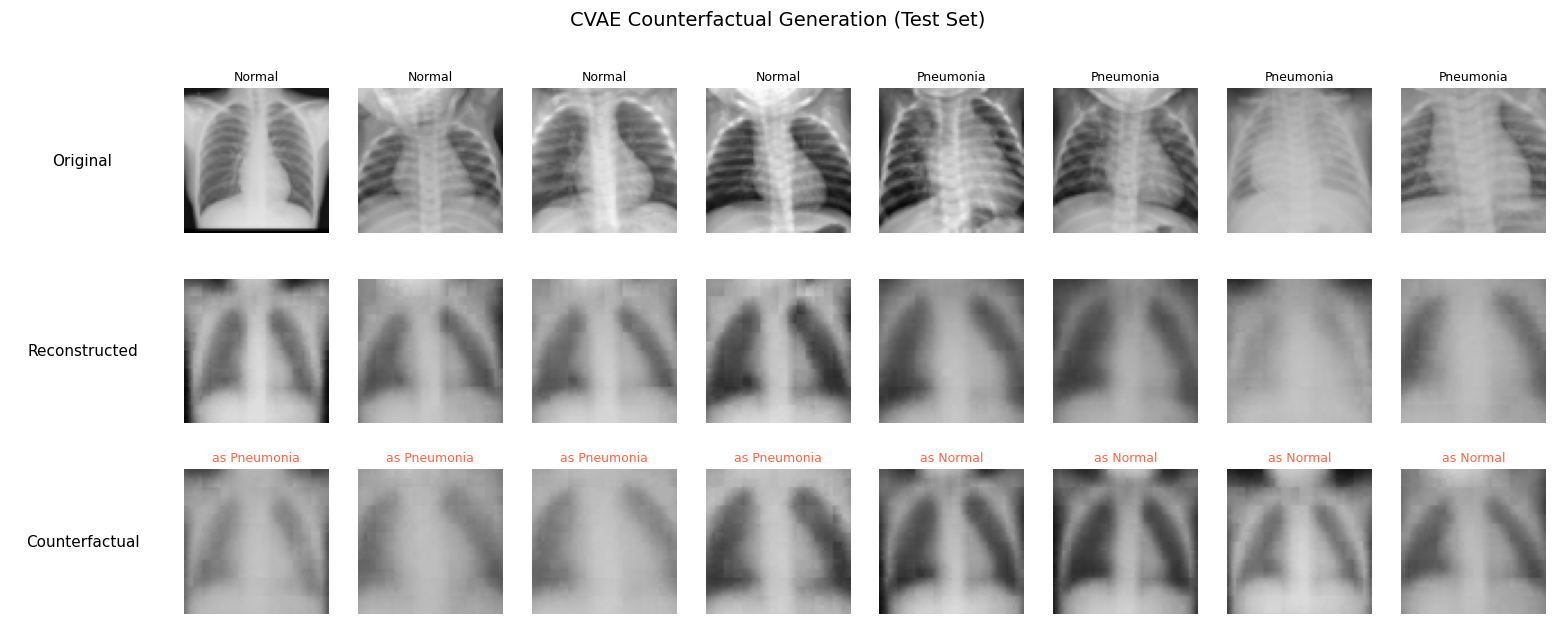

In [12]:
np.random.seed(1090)
cvae.eval()

# Sample 4 normal and 4 pneumonia from test set
normal_idxs    = np.where(y_test == 0)[0]
pneumonia_idxs = np.where(y_test == 1)[0]
idxs = np.concatenate([np.random.choice(normal_idxs,    4, replace=False),
                        np.random.choice(pneumonia_idxs, 4, replace=False)])

with torch.no_grad():
    x_orig  = X_test_t[idxs].to(device)
    c_true  = torch.tensor(y_test[idxs], dtype=torch.long).to(device)
    c_swap  = 1 - c_true

    mu, log_var = cvae.encode(x_orig, c_true)
    z           = cvae.reparameterize(mu, log_var)
    x_recon     = cvae.decode(z, c_true)
    x_counter   = cvae.decode(z, c_swap)

    x_orig    = x_orig.cpu().numpy()
    x_recon   = x_recon.cpu().numpy()
    x_counter = x_counter.cpu().numpy()

# Plot original, reconstruction, and counterfactual
fig, axes = plt.subplots(3, 9, figsize=(16, 6))

for row, row_label in enumerate(['Original', 'Reconstructed', 'Counterfactual']):
    axes[row, 0].text(0.5, 0.5, row_label, fontsize=11, va='center', ha='center',
                      transform=axes[row, 0].transAxes)
    axes[row, 0].axis('off')

for j in range(8):
    axes[0, j+1].imshow(x_orig[j, 0],    cmap='gray', vmin=0, vmax=1)
    axes[1, j+1].imshow(x_recon[j, 0],   cmap='gray', vmin=0, vmax=1)
    axes[2, j+1].imshow(x_counter[j, 0], cmap='gray', vmin=0, vmax=1)
    for row in range(3):
        axes[row, j+1].axis('off')

    true_label = 'Normal'    if y_test[idxs[j]] == 0 else 'Pneumonia'
    swap_label = 'Pneumonia' if y_test[idxs[j]] == 0 else 'Normal'
    axes[0, j+1].set_title(true_label,      fontsize=9)
    axes[2, j+1].set_title(f"as {swap_label}", fontsize=9, color='tomato')

plt.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.02)
plt.suptitle('CVAE Counterfactual Generation (Test Set)', fontsize=14, y = 1.04)
plt.show()

> **❓ Question 4: Reflecting on Counterfactual Generation**
>
> Look carefully at the counterfactual images generated above.
>
> 1. Compare the original Pneumonia images to their "as Normal" counterfactuals, and the original Normal images to their "as Pneumonia" counterfactuals. What visual differences do you notice? What does this suggest the CVAE has learned about the visual signature of pneumonia?
>
> 2. The outputs are somewhat blurry. This is a known limitation of VAE-based generation. What is the fundamental reason for this blurriness, and how does it relate to the reconstruction loss we used?
>
> 3. CVAEs have real clinical appeal as a tool for counterfactual reasoning. What is one reason you should be cautious about trusting these generated images in a real medical setting?

<details>
<summary><em>Click to reveal answer</em></summary>

> 1. **Pneumonia to Normal**: the diffuse white opacity and cloudiness characteristic of pneumonia tends to clear in the counterfactual, producing a darker, more uniform lung field. **Normal to Pneumonia**: the counterfactuals develop increased brightness and haziness in the lung regions. This suggests the CVAE has genuinely learned that increased opacity and white clouding are the visual signature of pneumonia, and is applying this knowledge when flipping the condition label.
>
> 2. **Blurriness comes from MSE reconstruction loss**: MSE penalizes the average pixel-wise difference between the input and reconstruction. When the model is uncertain about fine details, the safest prediction is the average of all plausible outputs, which produces a blurry image. Perceptual losses or adversarial training (as in GANs) can mitigate this.
>
> 3. **Clinical caution**: The CVAE generates a *plausible* counterfactual based on patterns learned from training data, but it is not a ground truth. The model has no understanding of underlying physiology: it is pattern-matching, not reasoning. A generated "healthy" version of a pneumonia X-ray could look convincing while being anatomically incorrect in subtle but clinically important ways.

</details>